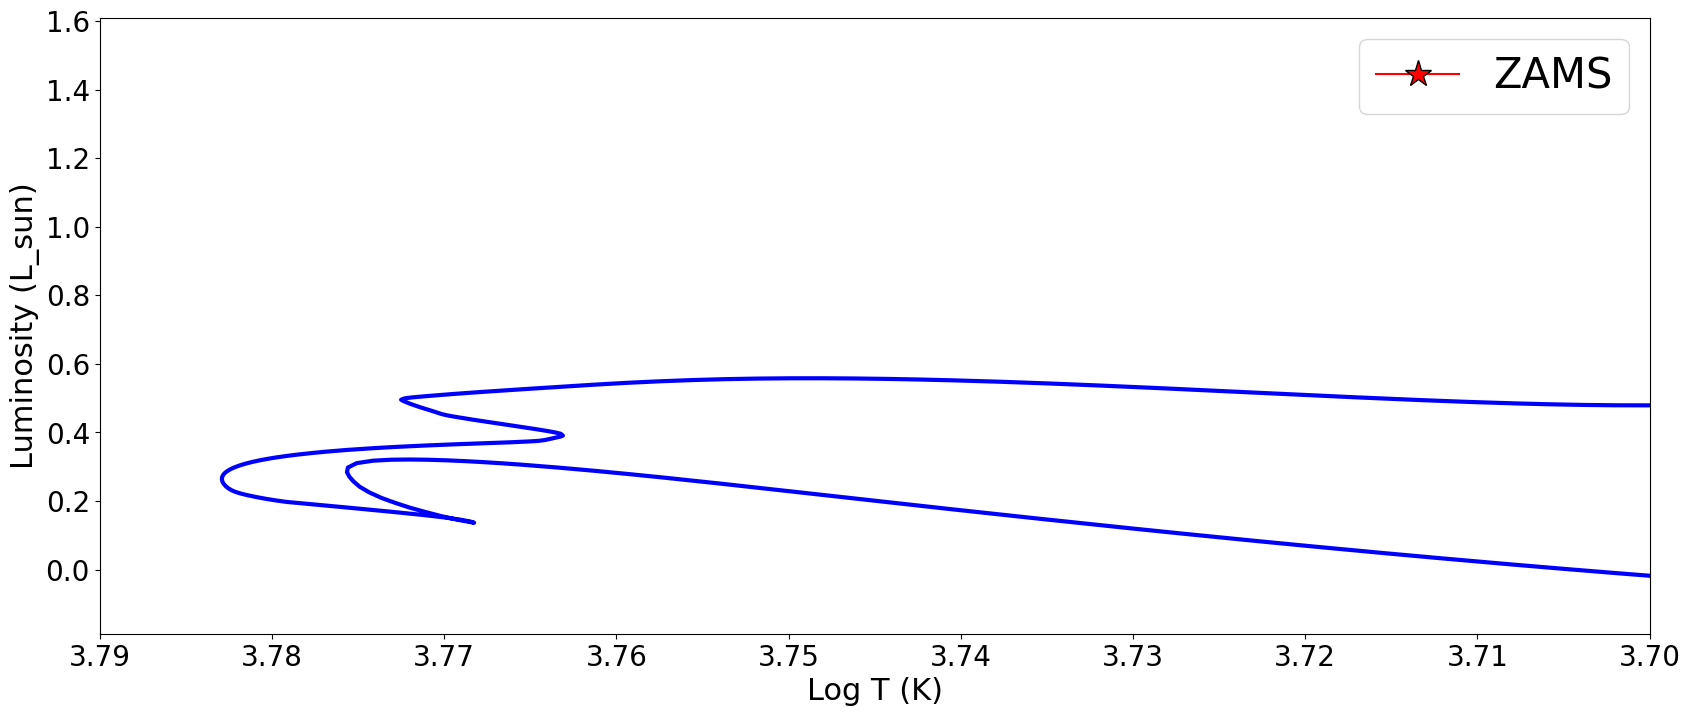

In [17]:
import kiauhoku as kh,matplotlib.pyplot as plt, numpy as np, pandas as pd

%matplotlib inline

grid = kh.load_interpolator('rocrit') #rocrit
# Stellar Grids: https://zenodo.org/records/11264222
# fastlaunch
# slowlaucnh
# rocrit
# mist - kernels dies
# yrec
# garstec - no Prot
# dartmouth - no Prot

# star = grid.get_star_eep((1.2295, 0.36,0,574)) # [mass, [Fe/H], [alpha/H], EEP], assuming solar alpha-abundance ([alpha/H]=0)
# print(star['Prot(days)'])
track = grid.get_track((1.2295, 0.36,0))# [mass, [Fe/H], [alpha/H]], assuming solar alpha-abundance ([alpha/H]=0)

plt.figure(figsize=(20,8))
luminosity = track['L/Lsun']
temp = track['Log Teff(K)']
temp_mask = (track['Log Teff(K)'] <3.79) & (track['Log Teff(K)']>3.76)
zams_index = np.argmin(track['L/Lsun'][temp_mask])
# index = np.argmax(track['logg'])
# period_index = (track['Prot(days)'][index:]).reset_index(drop=True)
# logg_index = (track['logg'][index:]).reset_index(drop=True)
# RG_period_mask = (period_index >=100) & (period_index <= 1000)
# MS_period_mask = (period_index >=20) & (period_index <= 30)

# Prot_new = np.array(period_index[RG_period_mask])
# Prot_MS = np.array(period_index[MS_period_mask])
# logg_new = np.array(logg_index[RG_period_mask])
# logg_MS = np.array(logg_index[MS_period_mask])
# ZAMS_idx = 19
# print(track['Prot(days)'][np.argmax(track['logg'])])
# plt.semilogx(period_index,logg_index,'b',lw=3)
plt.plot(track['Log Teff(K)'],np.log10(track['L/Lsun']),'b',lw=3)
plt.plot(track['Log Teff(K)'][zams_index],np.log10(track['L/Lsun'])[zams_index],
             'r',marker='*',markeredgecolor='k',markersize=20, label='ZAMS')
plt.xlabel("Log T (K)",fontsize = 22)
plt.ylabel("Luminosity (L_sun)",fontsize = 22)
# print(np.argmin(track['L/Lsun'][log_temp_mask]))
# plt.semilogx(Prot_new,logg_new,'r',lw=3, label='Red Giant Branch')
# plt.semilogx(Prot_MS,logg_MS,'m',lw=3, label='Main Sequence Branch')
# plt.semilogx(Prot_MS[ZAMS_idx],logg_MS[ZAMS_idx],'orange', marker = '*', markeredgecolor='k',markersize=15, label='ZAMS')
# plt.axhline(3.0273,c='k', linestyle=":",linewidth=3.0)
# plt.axvline(826.047, c = 'k', linestyle=":",linewidth=3.0)
# plt.text(250,3.0,'826.047 d',fontsize=35)

# plt.ylim(4.5,2.5)
plt.xlim(3.79,3.7)
plt.tick_params(axis='both', which='major', labelsize=20)
# plt.xlabel(r'$\log(\text{Rotation Period/days})$',fontsize=35)
# plt.ylabel(r'logg (dex)',fontsize=35)
plt.legend(loc='upper right', fontsize=30)
# plt.savefig('Rot_period.png', dpi=100, facecolor='w', bbox_inches='tight')
# plt.close()

ZAMS index: 201
ZAMS luminosity: 1.3696 Lsun
ZAMS log luminosity: 1.3696
ZAMS log Teff: 3.7683


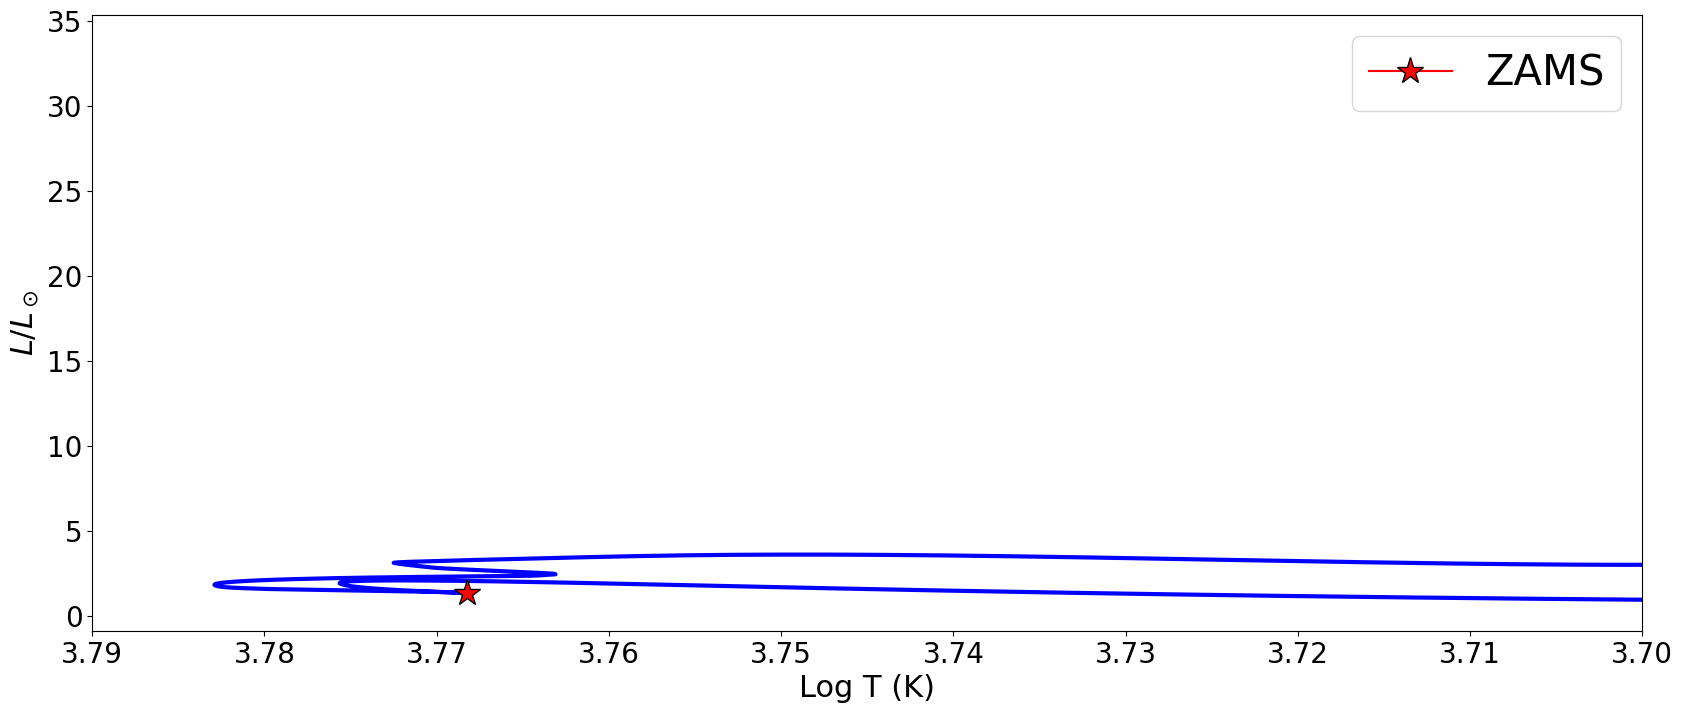

In [21]:
track = grid.get_track((1.2295, 0.36, 0))

temp = track['Log Teff(K)']
lum = track['L/Lsun']

temp_mask = (temp < 3.79) & (temp > 3.76)

zams_index = lum[temp_mask].idxmin()

zams_L = lum.loc[zams_index]
zams_logL = zams_L
zams_Teff = temp.loc[zams_index]

print(f"ZAMS index: {zams_index}")
print(f"ZAMS luminosity: {zams_L:.4f} Lsun")
print(f"ZAMS log luminosity: {zams_logL:.4f}")
print(f"ZAMS log Teff: {zams_Teff:.4f}")

plt.figure(figsize=(20, 8))

plt.plot(temp, lum, 'b', lw=3)

plt.plot(
    temp.loc[zams_index],
    lum.loc[zams_index],
    'r',
    marker='*',
    markeredgecolor='k',
    markersize=20,
    label='ZAMS'
)

plt.xlabel("Log T (K)", fontsize=22)
plt.ylabel(r"$L/L_\odot$", fontsize=22)
plt.xlim(3.79, 3.7)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.legend(loc='upper right', fontsize=30)
plt.show()

In [54]:
import pandas as pd
import numpy as np

# Current semi-major axis of KOI_6194b
a_AU = 0.25469955 # AU
mcmc_R = 5.6323       # R/Rsun
keck_Teff = 4725.29   # K
T_sun = 5777          # K

track = grid.get_track((1.2295, 0.36, 0))
temp_log = track['Log Teff(K)']
lum = track['L/Lsun']
radius = track['R/Rsun']

temp_mask = (temp_log < 3.79) & (temp_log > 3.76)

zams_index = lum[temp_mask].idxmin()

zams_L = lum.loc[zams_index]
zams_R = radius.loc[zams_index]
zams_Teff_log = temp_log.loc[zams_index]
zams_Teff = 10**zams_Teff_log

# Modelled ZAMS incident flux of KOI_6194b in Earth units
incident_flux_earth = zams_L / a_AU**2

# MCMC luminosity in solar units
L_mcmc = mcmc_R**2 * (keck_Teff / T_sun)**4

# Incident flux in Earth units
S_mcmc = L_mcmc / a_AU**2

# Existing model/ZAMS values
L_model = zams_L
R_model = zams_R
S_model = incident_flux_earth

summary_df = pd.DataFrame({
    "Quantity": ["Radius","Luminosity","Incident flux (0.25 AU)"],
    "MCMC / observed": [mcmc_R,L_mcmc,S_mcmc],
    "Model / ZAMS": [R_model,L_model,S_model],
    "Absolute change": [mcmc_R - R_model,L_mcmc - L_model,S_mcmc - S_model],
    "Ratio": [mcmc_R / R_model,L_mcmc / L_model,S_mcmc / S_model],
    "Units": [r"Rsun",r"Lsun",r"Searth"]
})

summary_df

,Quantity,MCMC / observed,Model / ZAMS,Absolute change,Ratio,Units
0,Radius,5.632300,1.123670,4.508630,5.012413,Rsun
1,Luminosity,14.199595,1.369626,12.829969,10.367501,Lsun
2,Incident flux (0.25 AU),218.886815,21.112784,197.774030,10.367501,Searth


plot temp and luminosity ==> HR

In [8]:
df = pd.DataFrame(track)
df.columns

Index(['Age(Gyr)', 'L/Lsun', 'R/Rsun', 'Log Teff(K)', 'Mcz(Msun)', 'Rcz(Rsun)',
       'Xcen', 'Itot(cgs)', 'Icz(cgs)', 'Tau(cz)(sec)', 'He Core(Msun)',
       'Patm(cgs)', 'Mass(Msun)', 'Prot(days)', 'Icore(cgs)', 'Omega(core)',
       'Omega(env)', 'Jtot(cgs)', 'Jcore(cgs)', 'Jenv(cgs)', 'logg',
       'logT(cen)', 'logrho(cen)', 'Ycen', 'XC12cen', 'Xsurf', 'Ysurf',
       'Z/X(surf)', 'H lum (Lsun)', 'He lum (Lsun)'],
      dtype='str')